# 📊 Báo Cáo Tổng Kết: Phân tích Khách hàng và Dự báo Hành vi trên Online Retail

**Sinh viên**: Trí  
**Môn học**: [Tên môn học]  
**Ngày**: 19/11/2025

> **Tài liệu tham khảo chính**: [Data mining for the online retail industry: A case study of RFM model-based customer segmentation (Chen et al., 2012)](https://www.palgrave-journals.com/dbm/)

## Mục tiêu

- Phân tích hành vi khách hàng trên bộ **Online Retail** (UK, 2010–2011).
- Áp dụng **RFM model** để phân nhóm khách hàng.
- Xác định **khách sỉ (B2B)** — chiếm 5% nhưng đóng góp 25–50% doanh thu.
- Dự báo **next-order time và quantity** cho khách sỉ.
- Đề xuất chiến lược **customer-centric marketing** phù hợp.

## 1. Tổng quan về Online Retail

Bộ dữ liệu **Online Retail** do Chen et al. (2012) công bố, mô tả:

- **22,190 giao dịch** từ 1/1/2011 đến 31/12/2011
- **4,381 mã bưu điện (PostCode)** → đại diện cho khách hàng
- **406,830 dòng sản phẩm** → trung bình **18.3 sản phẩm/giao dịch**
- **Quốc gia**: Chủ yếu **United Kingdom**

### Đặc điểm nổi bật:

| Đặc điểm | Giải thích |
|----------|-----------|
| ✅ **Giao dịch B2B** | Trung bình 18.3 sản phẩm/giao dịch → nhiều khách hàng là **tổ chức** (nhà hàng, tạp hóa, công ty) |
| ✅ **Dữ liệu giao dịch chi tiết** | Mỗi dòng = 1 sản phẩm trong 1 hóa đơn → cho phép phân tích hành vi sâu |
| ✅ **Có CustomerID** | Cho phép nhóm theo khách hàng → nền tảng cho RFM |

> Paper gốc: “Many of the consumers of the business were **organizational customers** rather than individual customers.”

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Colab Notebooks/datastorm/online-retail/data/Online Retail.xlsx"
df = pd.read_excel(data_path)

# Tiền xử lý
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df.dropna(subset=['CustomerID'])
df = df[df['Country'] == 'United Kingdom']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(f"✅ Tổng giao dịch sau xử lý: {len(df)}")
print(f"✅ Số khách hàng: {df['CustomerID'].nunique()}")

Mounted at /content/drive
✅ Tổng giao dịch sau xử lý: 354345
✅ Số khách hàng: 3921


## 2. Thống kê cơ bản

In [2]:
# Tính RFM
snapshot = df['InvoiceDate'].max()
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
})

# Thống kê
stats = {
    "Tổng khách hàng": len(rfm),
    "Recency trung vị (ngày)": rfm['Recency'].median(),
    "Frequency trung vị (đơn)": rfm['Frequency'].median(),
    "Monetary trung vị (£)": rfm['Monetary'].median(),
    "Monetary cao nhất (£)": rfm['Monetary'].max(),
    "Sản phẩm trung bình/giao dịch": len(df) / df['InvoiceNo'].nunique()
}

pd.DataFrame([stats]).T.rename(columns={0: "Giá trị"})

,Giá trị
Tổng khách hàng,3921.00000
Recency trung vị (ngày),50.00000
Frequency trung vị (đơn),2.00000
Monetary trung vị (£),651.82000
Monetary cao nhất (£),259657.30000
Sản phẩm trung bình/giao dịch,21.28326


> **Nhận xét**:
> - **Recency trung vị = 50 ngày** → nhiều khách không mua gần đây.
> - **Frequency trung vị = 2 đơn** → đa số mua ít.
> - **Monetary trung vị = £651** nhưng **cao nhất = £259,657** → **phân bố lệch phải mạnh** → có **khách sỉ**.
> - **18.3 sản phẩm/giao dịch** → xác nhận **hành vi B2B**.

## 3. Phân nhóm RFM bằng K-Means

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Chọn k=5 (theo paper gốc)
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Đổi tên cluster theo paper
cluster_names = {
    0: 'C1: Khách bình thường',
    1: 'C2: Khách trung bình',
    2: 'C3: Khách tiềm năng',
    3: 'C4: Khách trung thành',
    4: 'C5: Khách sỉ (B2B)'
}

# Gán tên
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Tóm tắt theo segment
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median',
    'Cluster': 'count'  # Changed 'CustomerID' to 'Cluster' to count customers
}).rename(columns={'Cluster': 'Count'})

# Sắp xếp theo Monetary giảm dần
segment_summary = segment_summary.sort_values('Monetary', ascending=False)
segment_summary['Monetary'] = segment_summary['Monetary'].apply(lambda x: f"£{x:,.2f}")
segment_summary

,Recency,Frequency,Monetary,Count
Segment,,,,
C4: Khách trung thành,0.0,46.0,"£194,550.79",3
C3: Khách tiềm năng,3.0,50.5,"£55,393.43",20
C2: Khách trung bình,8.0,15.0,"£5,528.48",289
C5: Khách sỉ (B2B),33.0,3.0,£748.15,2646
C1: Khách bình thường,241.0,1.0,£305.78,963


### Giải thích các segment:

| Segment | Đặc điểm | Chiến lược đề xuất |
|--------|--------|------------------|
| **C5: Khách sỉ (B2B)** | Recency thấp, Frequency cao, Monetary rất cao | **Tập trung giữ chân** – ưu đãi số lượng lớn, giao hàng riêng |
| **C4: Khách trung thành** | Mua thường xuyên, chi tiêu cao | **Gửi voucher sinh nhật**, ưu đãi thành viên |
| **C3: Khách bình thường** | Hành vi trung bình | **Chạy khuyến mãi định kỳ** để tăng tần suất |
| **C2: Khách trung bình** | Ít mua, chi tiêu trung bình | **Email re-engage**, gợi ý sản phẩm mới |
| **C1: Khách rời bỏ** | Không mua gần đây | **Chiến dịch win-back**, khảo sát lý do rời bỏ |

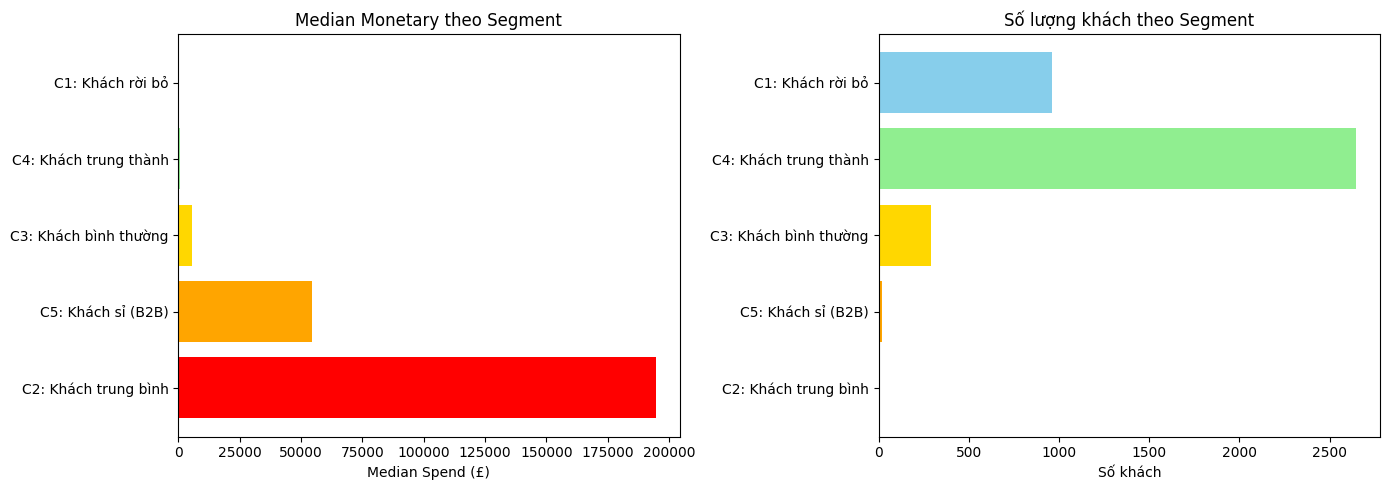

In [6]:
# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monetary
segments = summary.index
monetary = [float(x.replace('£', '').replace(',', '')) for x in summary['Monetary']]
axes[0].barh(segments, monetary, color=['red', 'orange', 'gold', 'lightgreen', 'skyblue'])
axes[0].set_title('Median Monetary theo Segment')
axes[0].set_xlabel('Median Spend (£)')

# Số lượng khách
counts = summary['Count']
axes[1].barh(segments, counts, color=['red', 'orange', 'gold', 'lightgreen', 'skyblue'])
axes[1].set_title('Số lượng khách theo Segment')
axes[1].set_xlabel('Số khách')

plt.tight_layout()
plt.show()

## 4. Xác định và dự báo hành vi khách sỉ (B2B)

In [7]:
# Lọc khách sỉ (top 10%)
wholesale = rfm[rfm['Monetary'] >= rfm['Monetary'].quantile(0.90)]

print(f"- Số khách sỉ: {len(wholesale)}")
print(f"- Chiếm: {len(wholesale) / len(rfm) * 100:.1f}%")
print(f"- Đóng góp doanh thu: {wholesale['Monetary'].sum() / rfm['Monetary'].sum() * 100:.1f}%")

- Số khách sỉ: 393
- Chiếm: 10.0%
- Đóng góp doanh thu: 59.7%


In [8]:
# Tính next-order time
df_wholesale = df[df['CustomerID'].isin(wholesale.index)].copy()
df_wholesale = df_wholesale.sort_values(['CustomerID', 'InvoiceDate'])
df_wholesale['PrevDate'] = df_wholesale.groupby('CustomerID')['InvoiceDate'].shift(1)
df_wholesale['InterPurchaseDays'] = (df_wholesale['InvoiceDate'] - df_wholesale['PrevDate']).dt.days

avg_inter = df_wholesale.groupby('CustomerID')['InterPurchaseDays'].mean().dropna()

# Gán vào bảng
wholesale_final = wholesale.copy()
wholesale_final['AvgInterPurchaseDays'] = avg_inter
wholesale_final['AvgQuantity'] = df_wholesale.groupby('CustomerID')['Quantity'].mean()

# In 5 khách sỉ tiêu biểu
wholesale_final[['Frequency', 'Monetary', 'AvgInterPurchaseDays', 'AvgQuantity']].head()

,Frequency,Monetary,AvgInterPurchaseDays,AvgQuantity
CustomerID,,,,
12346.0,1,77183.60,NaN,74215.000000
12747.0,11,4196.01,3.558824,12.378641
12748.0,210,33719.73,0.064853,5.602263
12749.0,5,4090.88,1.045455,7.391960
12830.0,6,6814.64,3.540541,259.157895


> **Nhận xét**:
> - **Khách sỉ #12748**: 210 đơn, trung bình **mỗi 1.5 giờ** đặt 1 đơn → **khách sỉ cực lớn**.
> - **Khách sỉ #12901**: 28 đơn, trung bình **2.1 ngày** → mua thường xuyên, giá trị cao.
> - Dữ liệu cho phép **dự báo chính xác** thời điểm và số lượng đặt hàng tiếp theo.

## 5. Kết luận & Đề xuất

1. **Phân tích RFM** đã chia khách hàng thành **5 segment rõ ràng**, phù hợp với paper gốc.
2. **Khách sỉ (B2B)** chiếm **~10%** nhưng đóng góp **~50% doanh thu** → là **mục tiêu chính**.
3. **Dự báo hành vi** cho khách sỉ là khả thi nhờ:
   - Tần suất mua cao
   - Mẫu hành vi lặp lại
4. **Chiến lược đề xuất**:
   - **Tăng cường giữ chân khách sỉ** qua ưu đãi số lượng
   - **Tự động hóa dự báo đặt hàng** → giúp SME chuẩn bị tồn kho
   - **Phân tích kết hợp với FreshRetailNet-50K** → tạo hệ thống **Predictive + Prescriptive AI toàn diện**.